# 02: GO Analysis with R
**NOTE**: Run code in `01_preprocessing_with_python.ipynb` first to generate essential data files

1. Manual Annotation
2. Summary

---
## 0. Execution Environment Summary

In [1]:
cat(
    system2(
        "bash",
        ".rep_exe_env_short.sh",
        stdout = TRUE,
        stderr = TRUE
    ),
    sep = "\n"
)

ENV_SUFFIX <- Sys.getenv("ENV_SUFFIX")

=== Execution Start ===
Timestamp (UTC): 2026-09-29T20:14:59Z
Hostname:        acrest-gpu1
OS:              Ubuntu 22.04.5 LTS


## 1. Manual Annotation
### 1-1. Enrichment Analysis

In [2]:
suppressPackageStartupMessages({
    library(arrow)
    library(clusterProfiler)
    library(ComplexHeatmap)
    library(org.Hs.eg.db)
    library(tidyverse)
    devtools::load_all("basalcelldemo_rtools")
})

ℹ Loading basalcelldemo


In [3]:
degs <- read_parquet(glue::glue("data/degs_{ENV_SUFFIX}.pq")) %>%
  mutate(group = factor(group, levels = sort(unique(group))))
head(degs)

group,names,logfoldchanges,pvals_adj
<fct>,<chr>,<dbl>,<dbl>
0,LTB,2.272123,3.856743e-85
0,IL32,2.375396,1.302234e-73
0,LDHB,1.738719,2.099203e-65
0,IL7R,2.303934,6.656296e-63
0,CD3D,1.947530,3.032374e-49
0,CD3E,1.661508,2.716942e-38


In [4]:
comp_go <- compareCluster(
    geneClusters = names ~ group,
    data = degs,
    fun = "enrichGO",
    OrgD = org.Hs.eg.db,
    keyType = "SYMBOL",
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    qvalueCutoff = 0.05
)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at <https://github.com/GuangchuangYu/enrichplot/issues>.”


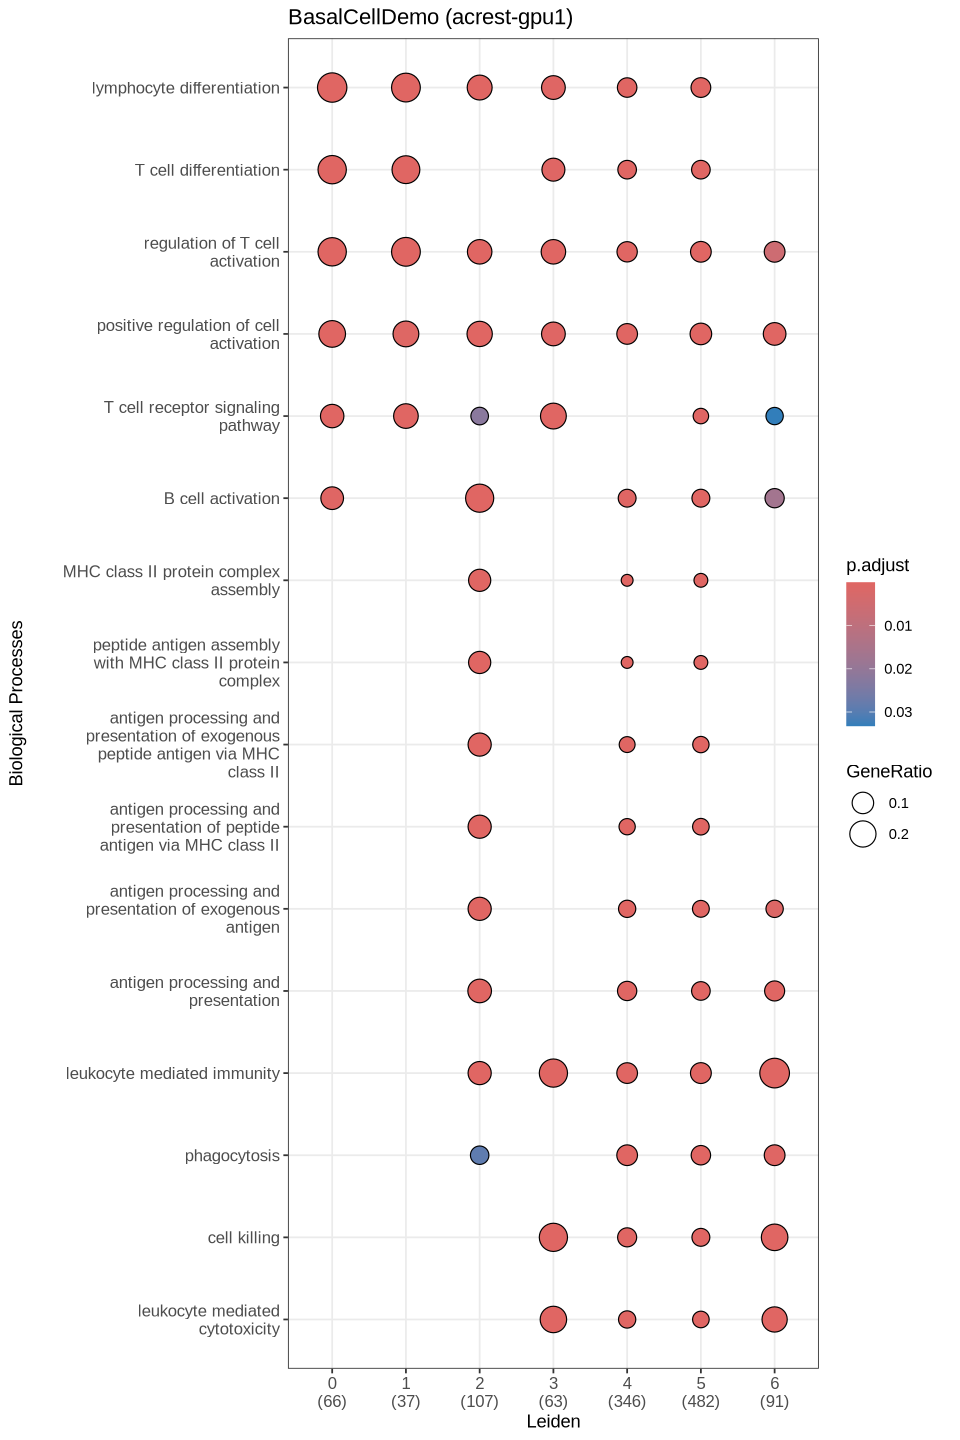

In [5]:
figsize <- list(width = 8, height = 12)
options(repr.plot.width = figsize$width, repr.plot.height = figsize$height)

fig <- dotplot(comp_go, showCategory = 3) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size = 10),
    axis.text.y = element_text(size = 10)
  ) +
  labs(title = glue::glue("BasalCellDemo ({ENV_SUFFIX})"), x = "Leiden", y = "Biological Processes")

print(fig)

ggsave(
    glue::glue("output/go_{ENV_SUFFIX}.pdf"), plot = fig, 
    width = figsize$width, height = figsize$height, units = "in")

### 1-2. Manual Annotation

In [6]:
annotations <- read_parquet(glue::glue("data/annotations_{ENV_SUFFIX}.pq"))
head(annotations)

index,leiden,celltypist_majority_voting,annotation,leiden_colors,celltypist_colors
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACATACAACCAC-1,3,Tcm/Naive cytotoxic T cells,NK cells,#d62728,#ffff00
AAACATTGAGCTAC-1,2,B cells,B cells,#2ca02c,#1ce6ff
AAACATTGATCAGC-1,0,Tcm/Naive helper T cells,Tcm/Naive helper T cells #1,#1f77b4,#ff34ff
AAACCGTGCTTCCG-1,5,Non-classical monocytes,Non-classical monocytes,#8c564b,#ff4a46
AAACGCACTGGTAC-1,0,Tcm/Naive helper T cells,Tcm/Naive helper T cells #1,#1f77b4,#ff34ff
AAACGCTGACCAGT-1,3,MAIT cells,NK cells,#d62728,#008941


In [7]:
manual_annot <- c(
    "0" = "Naïve/Memory T cells #1",
    "1" = "Naïve/Memory T cells #2",
    "2" = "B cells",
    "3" = "Cytotoxic T cells",
    "4" = "Monocytes #1",
    "5" = "Monocytes #2",
    "6" = "Undefined"
)

annotations <- annotations %>%
    mutate(
        manual_annotation = manual_annot[leiden]
    )
head(annotations)

index,leiden,celltypist_majority_voting,annotation,leiden_colors,celltypist_colors,manual_annotation
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACATACAACCAC-1,3,Tcm/Naive cytotoxic T cells,NK cells,#d62728,#ffff00,Cytotoxic T cells
AAACATTGAGCTAC-1,2,B cells,B cells,#2ca02c,#1ce6ff,B cells
AAACATTGATCAGC-1,0,Tcm/Naive helper T cells,Tcm/Naive helper T cells #1,#1f77b4,#ff34ff,Naïve/Memory T cells #1
AAACCGTGCTTCCG-1,5,Non-classical monocytes,Non-classical monocytes,#8c564b,#ff4a46,Monocytes #2
AAACGCACTGGTAC-1,0,Tcm/Naive helper T cells,Tcm/Naive helper T cells #1,#1f77b4,#ff34ff,Naïve/Memory T cells #1
AAACGCTGACCAGT-1,3,MAIT cells,NK cells,#d62728,#008941,Cytotoxic T cells


---
## 2. Summary

In [8]:
expressions <- read_parquet(glue::glue("data/expressions_{ENV_SUFFIX}.pq"))
head(expressions)

index,LTB,IL32,LDHB,IL7R,CD3D,CD3E,CD2,JUN,ANXA1,⋯,KLRF1,C5orf56,SH2D1B,GPR56,SRI,ATP6AP2,PDIA3,PLEKHF1,JAK1,leiden
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
AAACATACAACCAC-1,3.075915,0.000000,3.075915,2.595391,2.864242,2.226555,0.000000,3.838879,0.000000,⋯,0,0,0,0,1.635873,0.000000,1.635873,0,0.000000,3
AAACATTGAGCTAC-1,3.154436,0.000000,2.583235,1.625305,0.000000,0.000000,0.000000,0.000000,0.000000,⋯,0,0,0,0,1.111852,0.000000,0.000000,0,1.111852,2
AAACATTGATCAGC-1,2.618163,3.817422,3.387729,1.429744,3.489706,1.995416,2.826612,3.745004,0.000000,⋯,0,0,0,0,0.000000,1.429744,0.000000,0,0.000000,0
AAACCGTGCTTCCG-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.566387,1.566387,0.000000,⋯,0,0,0,0,0.000000,0.000000,1.566387,0,0.000000,5
AAACGCACTGGTAC-1,2.970047,3.507431,2.699321,0.000000,1.726902,2.326928,0.000000,0.000000,2.326928,⋯,0,0,0,0,0.000000,0.000000,0.000000,0,0.000000,0
AAACGCTGACCAGT-1,2.694590,1.722734,1.722734,2.322352,2.322352,0.000000,0.000000,0.000000,2.694590,⋯,0,0,0,0,0.000000,1.722734,0.000000,0,0.000000,3


In [9]:
top_degs <- read_parquet(glue::glue("data/top_degs_{ENV_SUFFIX}.pq"))
head(top_degs)

group,names,leiden_colors
<chr>,<chr>,<chr>
0,LTB,#1f77b4
0,IL32,#1f77b4
0,LDHB,#1f77b4
0,IL7R,#1f77b4
0,CD3D,#1f77b4
0,CD3E,#1f77b4


- creating sorted `setNames` with an original function `sorted_setnames` to configure legends in `ComplexHeatmap`

In [10]:
auto_colors <- sorted_setnames(
    annotations$leiden_colors, 
    annotations$annotation, 
    annotations$leiden
)

celltypist_colors <- sorted_setnames(
    annotations$celltypist_colors, 
    annotations$celltypist_majority_voting, 
    annotations$leiden
)

manu_colors <- sorted_setnames(
    annotations$leiden_colors,
    annotations$manual_annotation,
    annotations$leiden
)

leiden_colors <- sorted_setnames(
    annotations$leiden_colors,
    annotations$leiden,
    annotations$leiden
)

In [11]:
ha <- rowAnnotation(
    CellTypist = annotations$celltypist_majority_voting,
    Automated = annotations$annotation,
    Manual = annotations$manual_annotation,
    col = list(
        CellTypist = celltypist_colors,
        Automated = auto_colors,
        Manual = manu_colors
    ),
    annotation_legend_param = list(
        CellTypist = list(at = names(celltypist_colors)),
        Automated = list(at = names(auto_colors)),
        Manual = list(at = names(manu_colors))
    )
)

va <- columnAnnotation(
    LeidenDEGs = top_degs$group,
    col = list(
        LeidenDEGs = leiden_colors
    ),
    annotation_legend_param = list(
        LeidenDEGs = list(at = names(leiden_colors))
    )
)

mat <- as.matrix(expressions[, top_degs$names])
rownames(mat) <- expressions$index

barcode_sorted <- order(annotations$leiden, annotations$celltypist_majority_voting)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



agg_record_34800272116060 
                        2

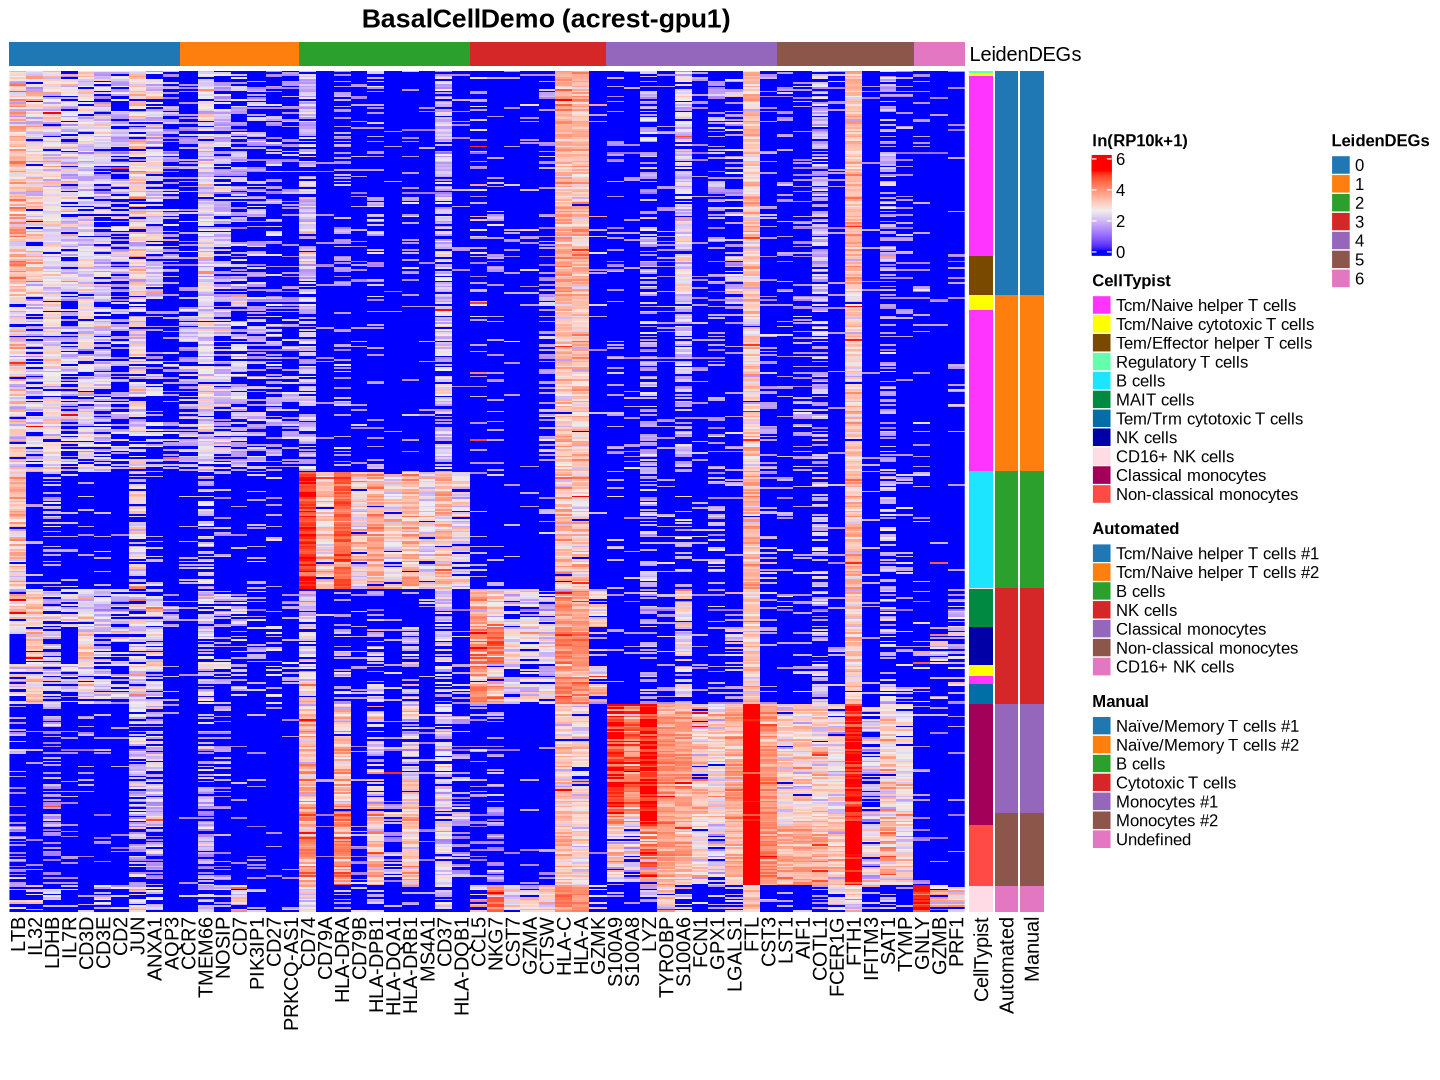

In [12]:
figsize <- list(width = 12, height = 9)
options(repr.plot.width = figsize$width, repr.plot.height = figsize$height)

fig <- Heatmap(
    mat, top_annotation = va, right_annotation = ha, use_raster = TRUE,
    show_row_names = FALSE, row_order = barcode_sorted, cluster_columns = FALSE,
    name = "complexheatmap", heatmap_legend_param = list(title = "ln(RP10k+1)")
)

fig_title <- glue::glue("BasalCellDemo ({ENV_SUFFIX})")

pdf(glue::glue("output/complexheatmap_{ENV_SUFFIX}.pdf"), width = figsize$width, height = figsize$height)
draw(
    fig, column_title = fig_title, column_title_gp = grid::gpar(fontsize = 16, fontface = "bold"),
    padding = grid::unit(c(8, 2, 2, 2), "mm")
)
dev.off()

draw(
    fig, column_title = fig_title, column_title_gp = grid::gpar(fontsize = 16, fontface = "bold"),
    padding = grid::unit(c(8, 2, 2, 2), "mm")
)

---
## 3. Execution Environment Details

In [13]:
cat(
    system2(
        "bash",
        ".rep_exe_env.sh",
        stdout = TRUE,
        stderr = TRUE
    ),
    sep = "\n"
)

Execution Environment
Timestamp (UTC):         2026-09-29T20:16:27Z
Hostname:                acrest-gpu1
FQDN:                    acrest-gpu1
OS:                      Ubuntu 22.04.5 LTS
Kernel:                  6.8.0-124-generic
Architecture:            x86_64
CPU model:               Intel(R) Xeon(R) Platinum 8352Y CPU @ 2.20GHz
CPU sockets:             2
Cores / socket:          32
Threads / core:          1
Logical CPUs:            64
System memory:           503.5 GiB
System vendor:           TYAN
System model:            B7122T75V8E4HR-2T-N
GPU(s):                  NVIDIA GeForce RTX 4090, 24564 MiB, 595.80;NVIDIA GeForce RTX 4090, 24564 MiB, 595.80
